# Data Analysis

Log

- 19/01/2025: Init

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data

In [2]:
fpath_records = './data/records.json'
def get_df() -> pd.DataFrame:
    return pd.read_json(fpath_records)

In [3]:
df = get_df()
print('df.shape: ', df.shape)
print('df ∑nRecords: ', df.nRecords.sum())
print('df head')
display(df.head(3))
print('df tail')
display(df.tail(3))

# df.records: each value in this column is a list of records
# a: dataframe with exploded df.records, i.e., each row corresponds to a single record object
a = df.explode('records',)
print('a.shape: ', a.shape)
display(a.head(3))

# b: dataframe created from the records objects
b = a.records.apply(pd.Series)
print('b.shape: ', b.shape)
display(b.head(3))

df.shape:  (600, 6)
df ∑nRecords:  4200
df head


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
0,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc02,0
1,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,vc02,0
2,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,vc02,0


df tail


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
597,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,vc02,149
598,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,vc02,149
599,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,ecdsa-sd-2023-cryptosuite,Implementation_EcdsaSd2023Cryptosuite,vc02,149


a.shape:  (4200, 6)


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
0,"{'name': 'START_SIGN_VC', 'entryType': 'mark',...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc02,0
0,"{'name': 'END_SIGN_VC', 'entryType': 'mark', '...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc02,0
0,"{'name': 'START_VERIFY_VC', 'entryType': 'mark...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc02,0


b.shape:  (4200, 5)


,name,entryType,startTime,duration,detail
0,START_SIGN_VC,mark,683.719584,0,{'implementation': 'bbs-bls-signature-2020'}
0,END_SIGN_VC,mark,819.508959,0,{'implementation': 'bbs-bls-signature-2020'}
0,START_VERIFY_VC,mark,820.111542,0,{'implementation': 'bbs-bls-signature-2020'}


`c = merge(a,b)`

In [4]:
c = a[['iteration','implementationClass', 'credentialSetupKey']]\
    .drop_duplicates()\
    .merge(b[['name', 'entryType', 'startTime']], left_index=True, right_index=True)
print('c.shape: ', c.shape)
display(c.head(3))

c.shape:  (4200, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc02,START_SIGN_VC,mark,683.719584
0,0,Implementation_BbsBlsSignature2020,vc02,END_SIGN_VC,mark,819.508959
0,0,Implementation_BbsBlsSignature2020,vc02,START_VERIFY_VC,mark,820.111542


Filter: only keep `mark` entries.

In [5]:
d = c[c.entryType == 'mark']
print('d.shape: ', d.shape)
d.head(3)

d.shape:  (4200, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc02,START_SIGN_VC,mark,683.719584
0,0,Implementation_BbsBlsSignature2020,vc02,END_SIGN_VC,mark,819.508959
0,0,Implementation_BbsBlsSignature2020,vc02,START_VERIFY_VC,mark,820.111542


Some final preprocessing.

In [6]:
e = d.drop('entryType', axis = 1) # We can drop the entryType as we already know all values are 'mark'.
# Extract implementation column.
e['implementation'] = e.implementationClass.str.split('_').apply(lambda x: x[-1])
e.drop('implementationClass', axis=1, inplace=True) # We no longer need this column.
# Extract step and step type from name as columns.
e['step'] = e['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
e['stepType'] = e['name'].apply(lambda x: x.split('_')[0])
e.drop('name', axis=1, inplace=True) # We no longer need this column.
print('e.shape: ', e.shape)
display(e.head(3))

e.shape:  (4200, 6)


,iteration,credentialSetupKey,startTime,implementation,step,stepType
0,0,vc02,683.719584,BbsBlsSignature2020,SIGN_VC,START
0,0,vc02,819.508959,BbsBlsSignature2020,SIGN_VC,END
0,0,vc02,820.111542,BbsBlsSignature2020,VERIFY_VC,START


## Analysis

In [7]:
def get_dfa() -> pd.DataFrame:
    """ Get the analysis dataframe """
    # Return a copy of the last dataframe result from the previous section
    return e.copy()

**Background** 

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [8]:
dfa = get_dfa()
dfa.set_index(['implementation', 'credentialSetupKey', 'iteration','step','stepType'], inplace=True)
print('dfa.shape: ', dfa.shape)
display(dfa.head(3))

dfa.shape:  (4200, 1)


startTime
implementation      credentialSetupKey iteration step      stepType            
BbsBlsSignature2020 vc02               0         SIGN_VC   START     683.719584
                                                           END       819.508959
                                                 VERIFY_VC START     820.111542

In [9]:
# Compute the duration delta between each step's start and end time
df_delta = dfa.startTime\
    .unstack('stepType')\
    .apply(lambda r: r.END - r.START, axis=1)\
    .to_frame('delta')
print('df_delta.shape: ', df_delta.shape)
display(df_delta.head(3))

df_delta.shape:  (2100, 1)


delta
implementation      credentialSetupKey iteration step                      
BbsBlsSignature2020 vc02               0         DERIVE          183.911917
                                                 SIGN_VC         135.789375
                                                 VERIFY_DERIVED   45.929833

`df_stat`: the DataFrame containing descriptive statistics from `df_delta`.

In [10]:
df_stat = df_delta.copy()
df_stat.reset_index(inplace=True)
agg_funcs = ['mean','std', 'var','min','max','count']
df_stat = df_stat.groupby(['implementation', 'credentialSetupKey', 'step'])['delta'].agg(agg_funcs)
df_stat

mean  \
implementation           credentialSetupKey step                         
BbsBlsSignature2020      vc02               DERIVE          168.811657   
                                            SIGN_VC          77.512446   
                                            VERIFY_DERIVED   46.277295   
                                            VERIFY_VC        49.344480   
BbsTermwiseSignature2023 vc02               DERIVE          181.733513   
                                            SIGN_VC          64.277737   
                                            VERIFY_DERIVED   85.680431   
                                            VERIFY_VC        75.573413   
EcdsaSd2023Cryptosuite   vc02               DERIVE           50.250102   
                                            SIGN_VC          43.589852   
                                            VERIFY_DERIVED   19.002691   
                                            VERIFY_VC        16.116686   
Ed25519Signature2020     vc02               SIGN_VC          16.181728   
                                            VERIFY_VC        15.737501   

                                                                  std  \
implementation           credentialSetupKey step                        
BbsBlsSignature2020      vc02               DERIVE          33.066153   
                                            SIGN_VC         11.137389   
                                            VERIFY_DERIVED   4.817791   
                                            VERIFY_VC        9.580963   
BbsTermwiseSignature2023 vc02               DERIVE          11.371255   
                                            SIGN_VC         13.795317   
                                            VERIFY_DERIVED  13.852206   
                                            VERIFY_VC       16.170814   
EcdsaSd2023Cryptosuite   vc02               DERIVE           9.216267   
                                            SIGN_VC          7.693460   
                                            VERIFY_DERIVED   7.001170   
                                            VERIFY_VC        4.745925   
Ed25519Signature2020     vc02               SIGN_VC          3.511074   
                                            VERIFY_VC        2.221744   

                                                                    var  \
implementation           credentialSetupKey step                          
BbsBlsSignature2020      vc02               DERIVE          1093.370450   
                                            SIGN_VC          124.041436   
                                            VERIFY_DERIVED    23.211110   
                                            VERIFY_VC         91.794843   
BbsTermwiseSignature2023 vc02               DERIVE           129.305443   
                                            SIGN_VC          190.310776   
                                            VERIFY_DERIVED   191.883623   
                                            VERIFY_VC        261.495240   
EcdsaSd2023Cryptosuite   vc02               DERIVE            84.939574   
                                            SIGN_VC           59.189332   
                                            VERIFY_DERIVED    49.016376   
                                            VERIFY_VC         22.523807   
Ed25519Signature2020     vc02               SIGN_VC           12.327640   
                                            VERIFY_VC          4.936148   

                                                                   min  \
implementation           credentialSetupKey step                         
BbsBlsSignature2020      vc02               DERIVE          150.317292   
                                            SIGN_VC          67.484083   
                                            VERIFY_DERIVED   42.489125   
                                            VERIFY_VC        44.734833   
BbsTermwiseSignature2023 vc02               DERIVE          172.763

`df_mean`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [11]:
step_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
df_mean = df_stat['mean']\
    .unstack(['implementation','credentialSetupKey'])\
    .reorder_levels(['credentialSetupKey','implementation'],axis=1)\
    .loc[step_order]\
    .round(2)
df_mean

credentialSetupKey                vc02                           \
implementation     BbsBlsSignature2020 BbsTermwiseSignature2023   
step                                                              
SIGN_VC                          77.51                    64.28   
VERIFY_VC                        49.34                    75.57   
DERIVE                          168.81                   181.73   
VERIFY_DERIVED                   46.28                    85.68   

credentialSetupKey                                              
implementation     EcdsaSd2023Cryptosuite Ed25519Signature2020  
step                                                            
SIGN_VC                             43.59                16.18  
VERIFY_VC                           16.12                15.74  
DERIVE                              50.25                  NaN  
VERIFY_DERIVED                      19.00                  NaN

Plotting (Seaborn)

In [12]:
dfsb = df_delta.reset_index()
print('dfsb.shape: ', dfsb.shape)
dfsb.head(3)

dfsb.shape:  (2100, 5)


,implementation,credentialSetupKey,iteration,step,delta
0,BbsBlsSignature2020,vc02,0,DERIVE,183.911917
1,BbsBlsSignature2020,vc02,0,SIGN_VC,135.789375
2,BbsBlsSignature2020,vc02,0,VERIFY_DERIVED,45.929833


In [13]:
implementation_order = sorted(dfsb.implementation.unique())
print(implementation_order)

['BbsBlsSignature2020', 'BbsTermwiseSignature2023', 'EcdsaSd2023Cryptosuite', 'Ed25519Signature2020']


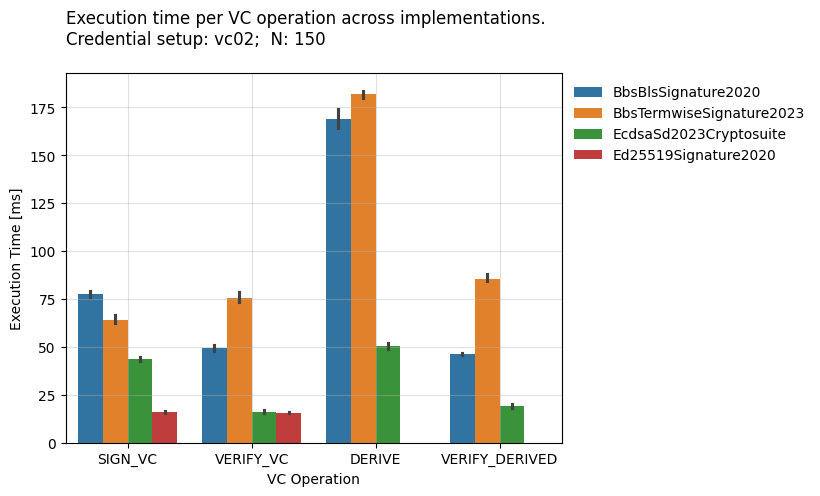

In [14]:
# Compute value counts for credentialSetupKey
csk_vc = dfsb['credentialSetupKey'].value_counts(dropna=False)
if csk_vc.shape[0] != 1:
    raise Exception('This plot is only valid for data sets with a single credentialSetupKey')

csk = csk_vc.index[0]
N = dfsb.iteration.max() + 1

ax = sns.barplot(
    data = dfsb,
    x = 'step',
    y = 'delta',
    hue = 'implementation',
    order=step_order,
    hue_order=implementation_order
)

ax.legend(frameon=False, bbox_to_anchor=(1,1))
ax.set_title(f'''Execution time per VC operation across implementations.
Credential setup: {csk};  N: {N}
''',loc='left')
ax.set_xlabel('VC Operation')
ax.set_ylabel('Execution Time [ms]')
ax.grid(alpha=.4)
plt.show()

In [15]:
df_mean

credentialSetupKey                vc02                           \
implementation     BbsBlsSignature2020 BbsTermwiseSignature2023   
step                                                              
SIGN_VC                          77.51                    64.28   
VERIFY_VC                        49.34                    75.57   
DERIVE                          168.81                   181.73   
VERIFY_DERIVED                   46.28                    85.68   

credentialSetupKey                                              
implementation     EcdsaSd2023Cryptosuite Ed25519Signature2020  
step                                                            
SIGN_VC                             43.59                16.18  
VERIFY_VC                           16.12                15.74  
DERIVE                              50.25                  NaN  
VERIFY_DERIVED                      19.00                  NaN

In [16]:
df_mean.to_clipboard(excel=True)